In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
import os

In [3]:
'''from pathlib import Path

#read in pickle file from data_processing outputs
project_root = Path.cwd().parents[1]   

pickle_path = project_root / "Data_Processing" / "outputs" / "df_y9c.pickle"
combined_df_2 = pd.read_pickle(pickle_path)

#format dates as dates
combined_df_2['quarter'] = pd.to_datetime(combined_df_2['quarter'])
combined_df_2['year'] = pd.to_datetime(combined_df_2['year'])
'''

'from pathlib import Path\n\n#read in pickle file from data_processing outputs\nproject_root = Path.cwd().parents[1]   \n\npickle_path = project_root / "Data_Processing" / "outputs" / "df_y9c.pickle"\ncombined_df_2 = pd.read_pickle(pickle_path)\n\n#format dates as dates\ncombined_df_2[\'quarter\'] = pd.to_datetime(combined_df_2[\'quarter\'])\ncombined_df_2[\'year\'] = pd.to_datetime(combined_df_2[\'year\'])\n'

In [4]:
path_output_ = r"../../Data_Processing/outputs/banks_y9c"
combined_df_2 =  pd.concat([
    pd.read_pickle(os.path.join(path_output_, file_))
    for file_ in os.listdir(path_output_)
    ],axis=0).reset_index(drop=True)

combined_df_2['quarter'] = pd.to_datetime(combined_df_2['quarter'])
combined_df_2['year'] = pd.to_datetime(combined_df_2['year'])

In [5]:
#define cumulative columns
cumulative_cols = [
'REVENUE',
'NET_INCOME',
'EBT',

'CHARGED_OFF_REAL_ESTATE',
'CHARGED_OFF_FARMERS',
'CHARGED_OFF_COMMERCE_INDUSTRY',
'CHARGED_OFF_HOUSEHOLDS',
'CHARGED_OFF_FOREIGN_GOV',
'CHARGED_OFF_LEASE_FINANCING',

'RECOVERIES_REAL_ESTATE',
'RECOVERIES_FARMERS',
'RECOVERIES_COMMERCE_INDUSTRY',
'RECOVERIES_HOUSEHOLDS',
'RECOVERIES_FOREIGN_GOV',
'RECOVERIES_LEASE_FINANCING',

'LOANS_LOSS_PROVISIONS'
]

#define asset columns (manually ordered for heatmaps)
assets = [
    'quarter',
    'TOTAL_ASSETS',
    'ASSETS_LOANSRECEIVABLES_INVESTMENT',
    'ASSETS_SECURITIES_AVAILABLESALE',
    'ASSETS_TRADINGASSETS',
    'ASSETS_FEDERALFUNDS_RESELL',
    'ASSETS_OTHERASSETS',
    'ASSETS_CASH_INTERESTBALANCES_DOMESTIC',
    'ASSETS_SECURITIES_HELDTOMATURITY',

    'ASSETS_CASH_INTERESTBALANCES_FOREIGN',
    'ASSETS_LOANSRECEIVABLES_SALE',
    'ASSETS_CASH_NONINTERESTBALANCES',
    'ASSETS_INVESTMENTS_SUBSIDIARIES',
    'ASSETS_FIXEDASSETS',
    'ASSETS_OTHERREALESTATE',
    'ASSETS_INVESTMENTS_REALESTATE',
    'ASSETS_FEDERALFUNDS_DOMESTIC',
]

#sort df
combined_df_2 = combined_df_2.sort_values(['legal_name', 'year', 'quarter'])

#create cumulative version of the cumulative columns
for col in cumulative_cols:
    new_col = f'Quarterly_{col}'
    combined_df_2[new_col] = (
        combined_df_2.groupby(['legal_name', 'year'])[col]
                   .diff()
    )

    #handle cululative columns in first quarters
    mask_first = combined_df_2.groupby(['legal_name', 'year']).cumcount() == 0
    combined_df_2.loc[mask_first, new_col] = combined_df_2.loc[mask_first, col]


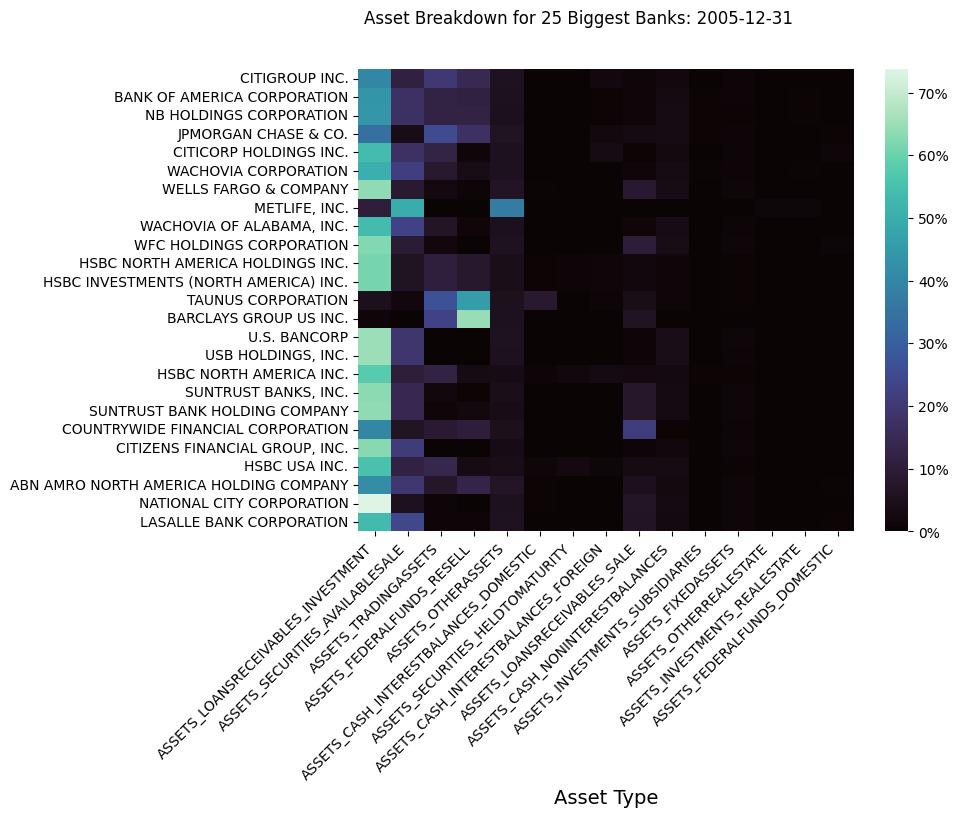

In [6]:
# Visualize asset breakdown for top n biggest banks for a given quarter

#set parameters
quarter_date = pd.to_datetime('2005-12-31')
n_biggest = 25

#sort by total assets
heatmap_combined_df = combined_df_2.sort_values(['legal_name','TOTAL_ASSETS', 'year', 'quarter'])
heatmap_combined_df = combined_df_2[(pd.to_datetime(combined_df_2['quarter']) == quarter_date)]

#keep only legal name and asset columns
cols_to_keep = ['legal_name'] + assets
filtered_df = heatmap_combined_df.filter(items=cols_to_keep, axis=1) # axis=1 specifies column filtering
filtered_df = filtered_df[filtered_df['TOTAL_ASSETS'] > 0]
filtered_df = filtered_df.sort_values('TOTAL_ASSETS', ascending=False)

#create proportion columns, assets as a portion of total assets
prop_assets = []
for item in assets[1:]:
    filtered_df[f'proportion_{item}'] = filtered_df[item] / filtered_df['TOTAL_ASSETS']
    prop_assets.append(f'proportion_{item}')
prop_assets.append('legal_name')

#keep n biggest banks
filtered_df = filtered_df[0:n_biggest]

#create data frame for the heatmap
heat_df = filtered_df.filter(items=prop_assets, axis=1)
heat_df = heat_df.set_index('legal_name')
heat_df.columns = heat_df.columns.str.replace('proportion_', '', regex=False)
heat_df = heat_df.drop(columns=['TOTAL_ASSETS'])

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(f'Asset Breakdown for {n_biggest} Biggest Banks: {quarter_date.date()}', x=.4)

sns.heatmap(heat_df, ax=ax, cbar_kws={"format": mtick.PercentFormatter(xmax=1.0)}, cmap = 'mako')
ax.set_ylabel('')
ax.set_xlabel('Asset Type', fontsize = 14)
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')



#save figure to outputs
plt.savefig('../outputs/Top_Banks_Asset_Breakdown.png', dpi=300)


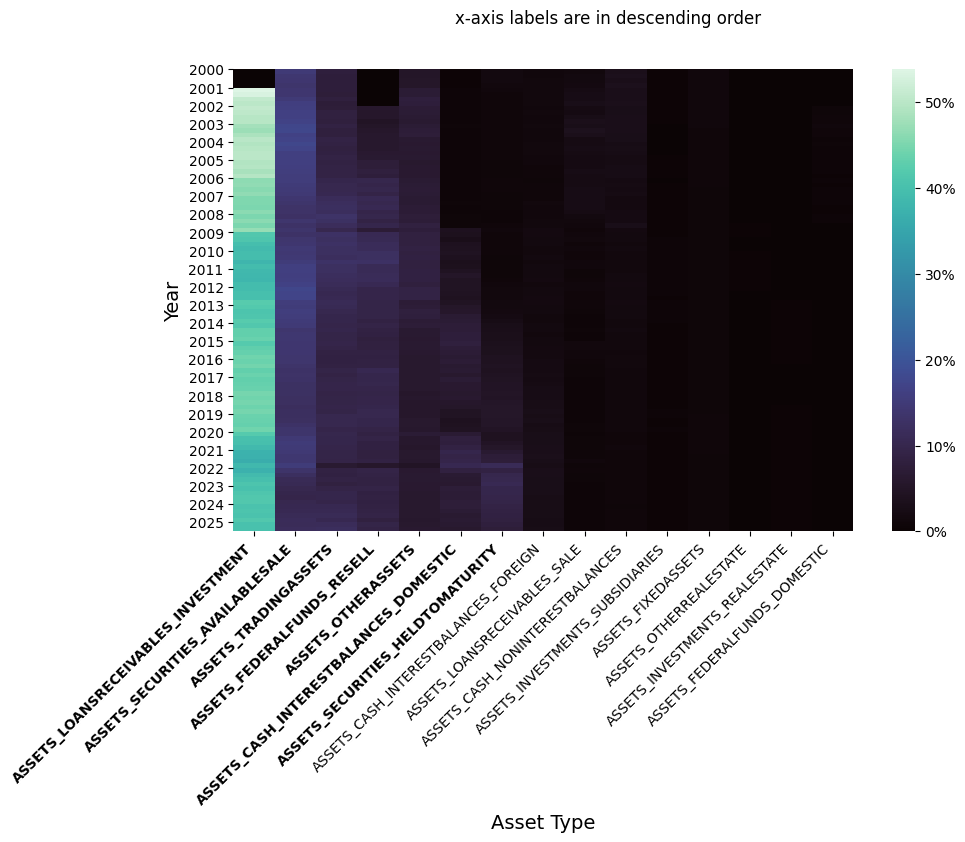

In [7]:
#Visualize assets across entire dataset

#group asset columns by quarter
quarter_group_df = (combined_df_2[assets].groupby('quarter').sum())


#create assets as proprotion of total assets
prop_by_quarter = quarter_group_df.div(quarter_group_df['TOTAL_ASSETS'], axis=0)
prop_by_quarter = prop_by_quarter.drop(columns=['TOTAL_ASSETS'])


fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('x-axis labels are in descending order')
sns.heatmap(prop_by_quarter, ax=ax, cbar_kws={"format": mtick.PercentFormatter(xmax=1.0)},yticklabels=False, cmap='mako')

#Get the year of reporting date every 4 rows so that ticks are years every 4th row
n = len(prop_by_quarter.index)
step = 4 
prop_by_quarter.index = prop_by_quarter.index.astype(str)
yticks = np.arange(0, n, step)
ylabels = prop_by_quarter.index[::step].str[:4]

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

xticklabels = ax.get_xticklabels()
ticks_to_bold = range(0,7)
for tick in ticks_to_bold:
    xticklabels[tick].set_fontweight('bold')


ax.set_ylabel('Year', fontsize = 14)
ax.set_xlabel('Asset Type', fontsize = 14)
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.savefig('../outputs/Asset_Proportions_Across_All_Banks.png', dpi=300)

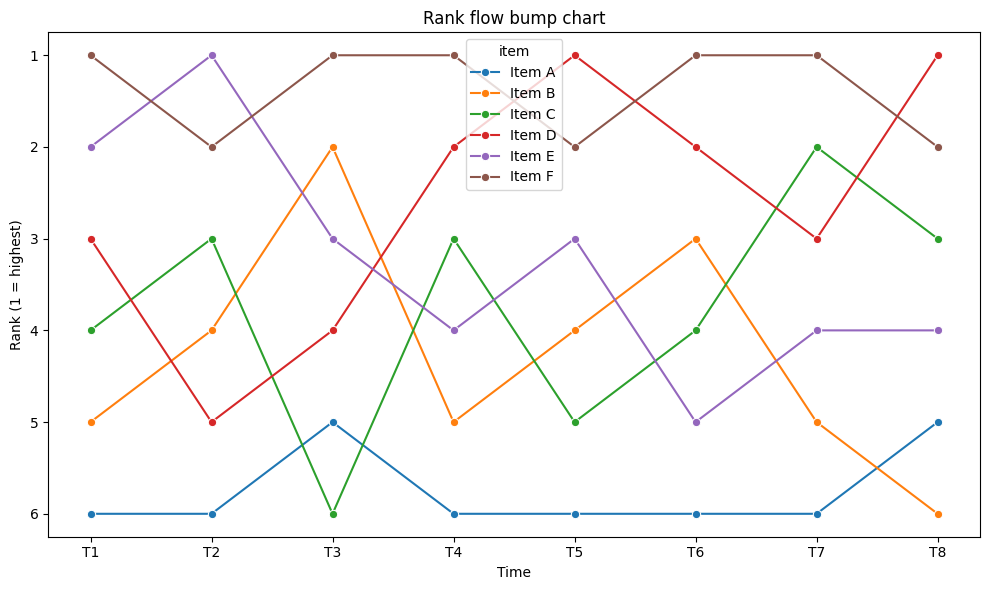

In [8]:
#chatgpt rank plot demo

# --- fake data: value of 6 items across 8 time points ---
np.random.seed(0)
times = [f"T{i}" for i in range(1, 9)]
items = [f"Item {c}" for c in ["A", "B", "C", "D", "E", "F"]]

rows = []
for t in times:
    for it in items:
        value = np.random.rand() + (items.index(it) * 0.2)  # just to give structure
        rows.append((t, it, value))

df = pd.DataFrame(rows, columns=["time", "item", "value"])

# --- compute rank per time (1 = highest value) ---
df["rank"] = df.groupby("time")["value"].rank(method="first", ascending=False)

# --- bump chart ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="time", y="rank", hue="item", marker="o")

plt.gca().invert_yaxis()              # rank 1 at top
plt.xlabel("Time")
plt.ylabel("Rank (1 = highest)")
plt.title("Rank flow bump chart")
plt.tight_layout()
plt.show()


In [9]:
#divide banks into top and bottom half

sorted_by_assets_df = combined_df_2.sort_values(
    ['legal_name', 'TOTAL_ASSETS']
)

top_half, bottom_half = np.array_split(sorted_by_assets_df, 2)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Text(0, 0.5, 'Charged Off Real Estate ($1000)')

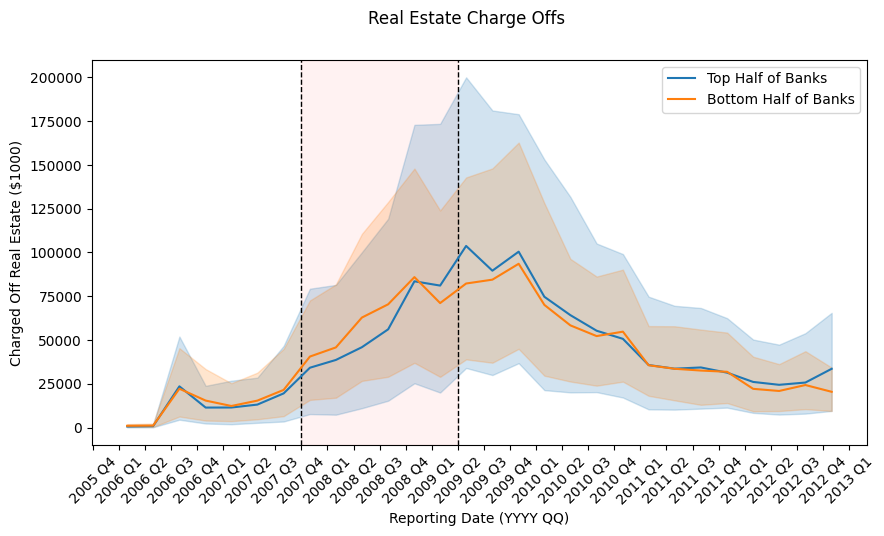

In [10]:
#visualize real estate chargeoffs

#set date range
start_date = pd.to_datetime('2006-01-01')
end_date = pd.to_datetime('2013-01-01')

#sort and filter data based on date range
sns_combined_df = combined_df_2.sort_values(['legal_name', 'year', 'quarter'])
sns_combined_df = combined_df_2[(pd.to_datetime(combined_df_2['quarter']) > start_date) & (pd.to_datetime(combined_df_2['quarter']) < end_date)]

#split banks into top and bottom halfs
sns_combined_df_top_half = sns_combined_df[sns_combined_df['legal_name'].isin(set(top_half['legal_name']))]
sns_combined_df_bottom_half = sns_combined_df[sns_combined_df['legal_name'].isin(set(bottom_half['legal_name']))]

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Real Estate Charge Offs')

#format ticks as year and quarter for readability
dates = sns_combined_df['quarter']
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

def quarter_fmt(x, pos):
    d = mdates.num2date(x)
    q = (d.month - 1) // 3 + 1
    return f"{d.year} Q{q}"

ax.xaxis.set_major_formatter(quarter_fmt)

#set column to be plotted
y = 'CHARGED_OFF_REAL_ESTATE'

#set vertical lines and shaded section on the graph
ax.axvline(x=pd.Timestamp("2007-12-01"), color='k', linestyle='--', linewidth=1)
ax.axvline(x=pd.Timestamp("2009-6-01"), color='k', linestyle='--', linewidth=1)

ax.axvspan(pd.Timestamp("2007-12-01"),
           pd.Timestamp("2009-06-01"),
           color='red',
           alpha=0.05)

sns.lineplot(data=sns_combined_df_top_half, x='quarter', y=y, label = 'Top Half of Banks')
sns.lineplot(data=sns_combined_df_bottom_half, x='quarter', y=y, label = 'Bottom Half of Banks')

ax.tick_params(axis='x', rotation=45)
ax.set_xlabel('Reporting Date (YYYY QQ)')
ax.set_ylabel('Charged Off Real Estate ($1000)')




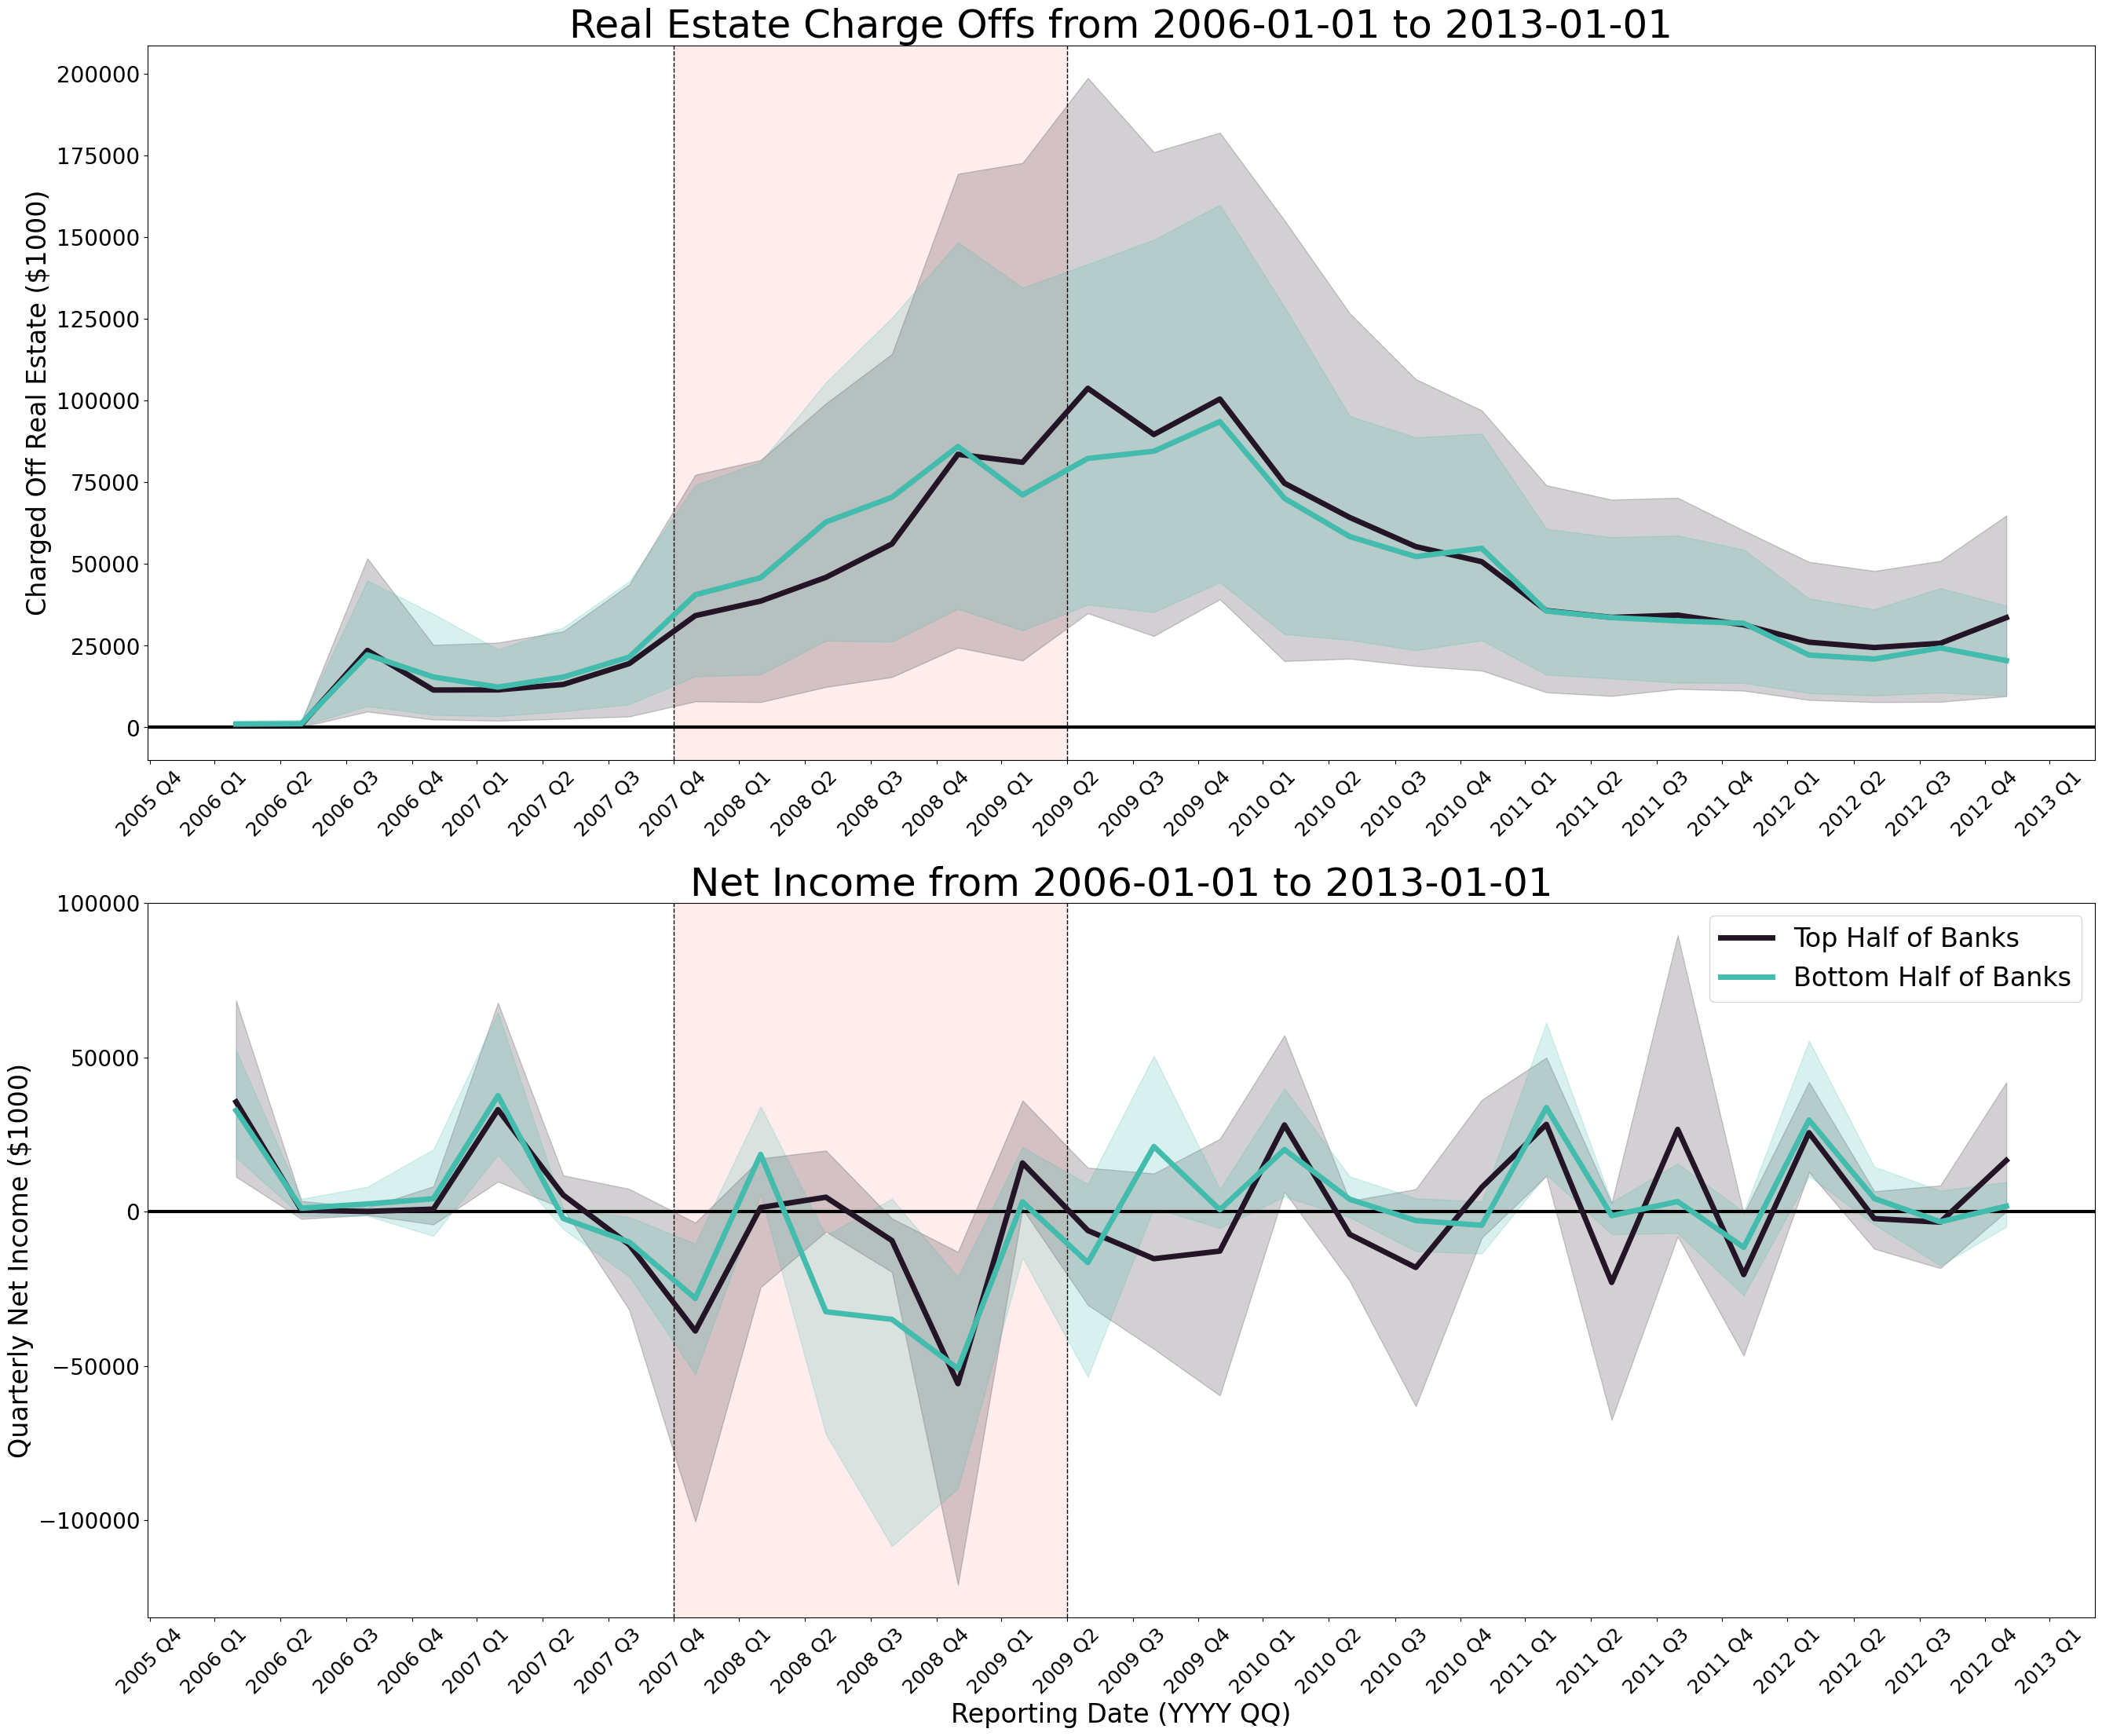

In [26]:
#create full figure of charge offs and net income over time

#set date range
start_date_string = '2006-01-01'
end_date_string = '2013-01-01'
start_date = pd.to_datetime(start_date_string)
end_date = pd.to_datetime(end_date_string)

#sort and filter data
sns_combined_df_2008 = combined_df_2.sort_values(['legal_name', 'year', 'quarter'])
sns_combined_df_2008 = combined_df_2[(pd.to_datetime(combined_df_2['quarter']) > start_date) & (pd.to_datetime(combined_df_2['quarter']) < end_date)]

#split banks into top and bottom half
sns_combined_df_top_half_2008 = sns_combined_df_2008[sns_combined_df_2008['legal_name'].isin(set(top_half['legal_name']))]
sns_combined_df_bottom_half_2008 = sns_combined_df_2008[sns_combined_df_2008['legal_name'].isin(set(bottom_half['legal_name']))]


fig, axes = plt.subplots(figsize=(32, 26), nrows = 2)


dates = sns_combined_df_2008['quarter']

axes[0].set_title(f'Real Estate Charge Offs from {start_date_string} to {end_date_string}', fontsize = 36)
axes[1].set_title(f'Net Income from {start_date_string} to {end_date_string}', fontsize = 36)

#set ticks as year and quarter for readability
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

def quarter_fmt(x, pos):
    d = mdates.num2date(x)
    q = (d.month - 1) // 3 + 1
    return f"{d.year} Q{q}"

axes[0].xaxis.set_major_formatter(quarter_fmt)
axes[1].xaxis.set_major_formatter(quarter_fmt)

#set column to be plotted
y = 'CHARGED_OFF_REAL_ESTATE'

#create vertical lines and shaded area
axes[0].axvline(x=pd.Timestamp("2007-12-01"), color='k', linestyle='--', linewidth=1)
axes[0].axvline(x=pd.Timestamp("2009-6-01"), color='k', linestyle='--', linewidth=1)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=3)

axes[0].axvspan(pd.Timestamp("2007-12-01"),
           pd.Timestamp("2009-06-01"),
           color='red',
           alpha=0.075)

axes[1].axvline(x=pd.Timestamp("2007-12-01"), color='k', linestyle='--', linewidth=1)
axes[1].axvline(x=pd.Timestamp("2009-6-01"), color='k', linestyle='--', linewidth=1)
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=3)

axes[1].axvspan(pd.Timestamp("2007-12-01"),
           pd.Timestamp("2009-06-01"),
           color='red',
           alpha=0.075)

top_half_color = sns.color_palette("mako", 10)[0]
bottom_half_color = sns.color_palette("mako", 10)[7]

sns.lineplot(data=sns_combined_df_top_half_2008, x='quarter', y=y, ax=axes[0], linewidth=5, color=top_half_color)
sns.lineplot(data=sns_combined_df_bottom_half_2008, x='quarter', y=y, ax=axes[0], linewidth=5, color=bottom_half_color)

sns.lineplot(data=sns_combined_df_top_half_2008, x='quarter', y='Quarterly_NET_INCOME', label = 'Top Half of Banks', ax=axes[1], linewidth=5, color=top_half_color)
sns.lineplot(data=sns_combined_df_bottom_half_2008, x='quarter', y='Quarterly_NET_INCOME', label = 'Bottom Half of Banks', ax=axes[1], linewidth=5, color=bottom_half_color)

axes[0].tick_params(axis='x', rotation=45, labelsize = 18)
axes[0].tick_params(axis='y', labelsize = 20)
axes[0].set_xlabel('')
axes[0].set_ylabel('Charged Off Real Estate ($1000)', fontsize = 24)

axes[1].tick_params(axis='x', rotation=45, labelsize = 18)
axes[1].tick_params(axis='y', labelsize = 20)
axes[1].set_xlabel('Reporting Date (YYYY QQ)', fontsize = 24)
axes[1].set_ylabel('Quarterly Net Income ($1000)', fontsize = 24)

plt.legend(fontsize=24)

plt.savefig('../outputs/2008_Real_Estate_Charge_Offs_And_Net_Income_Full_Figure.png', dpi=300)

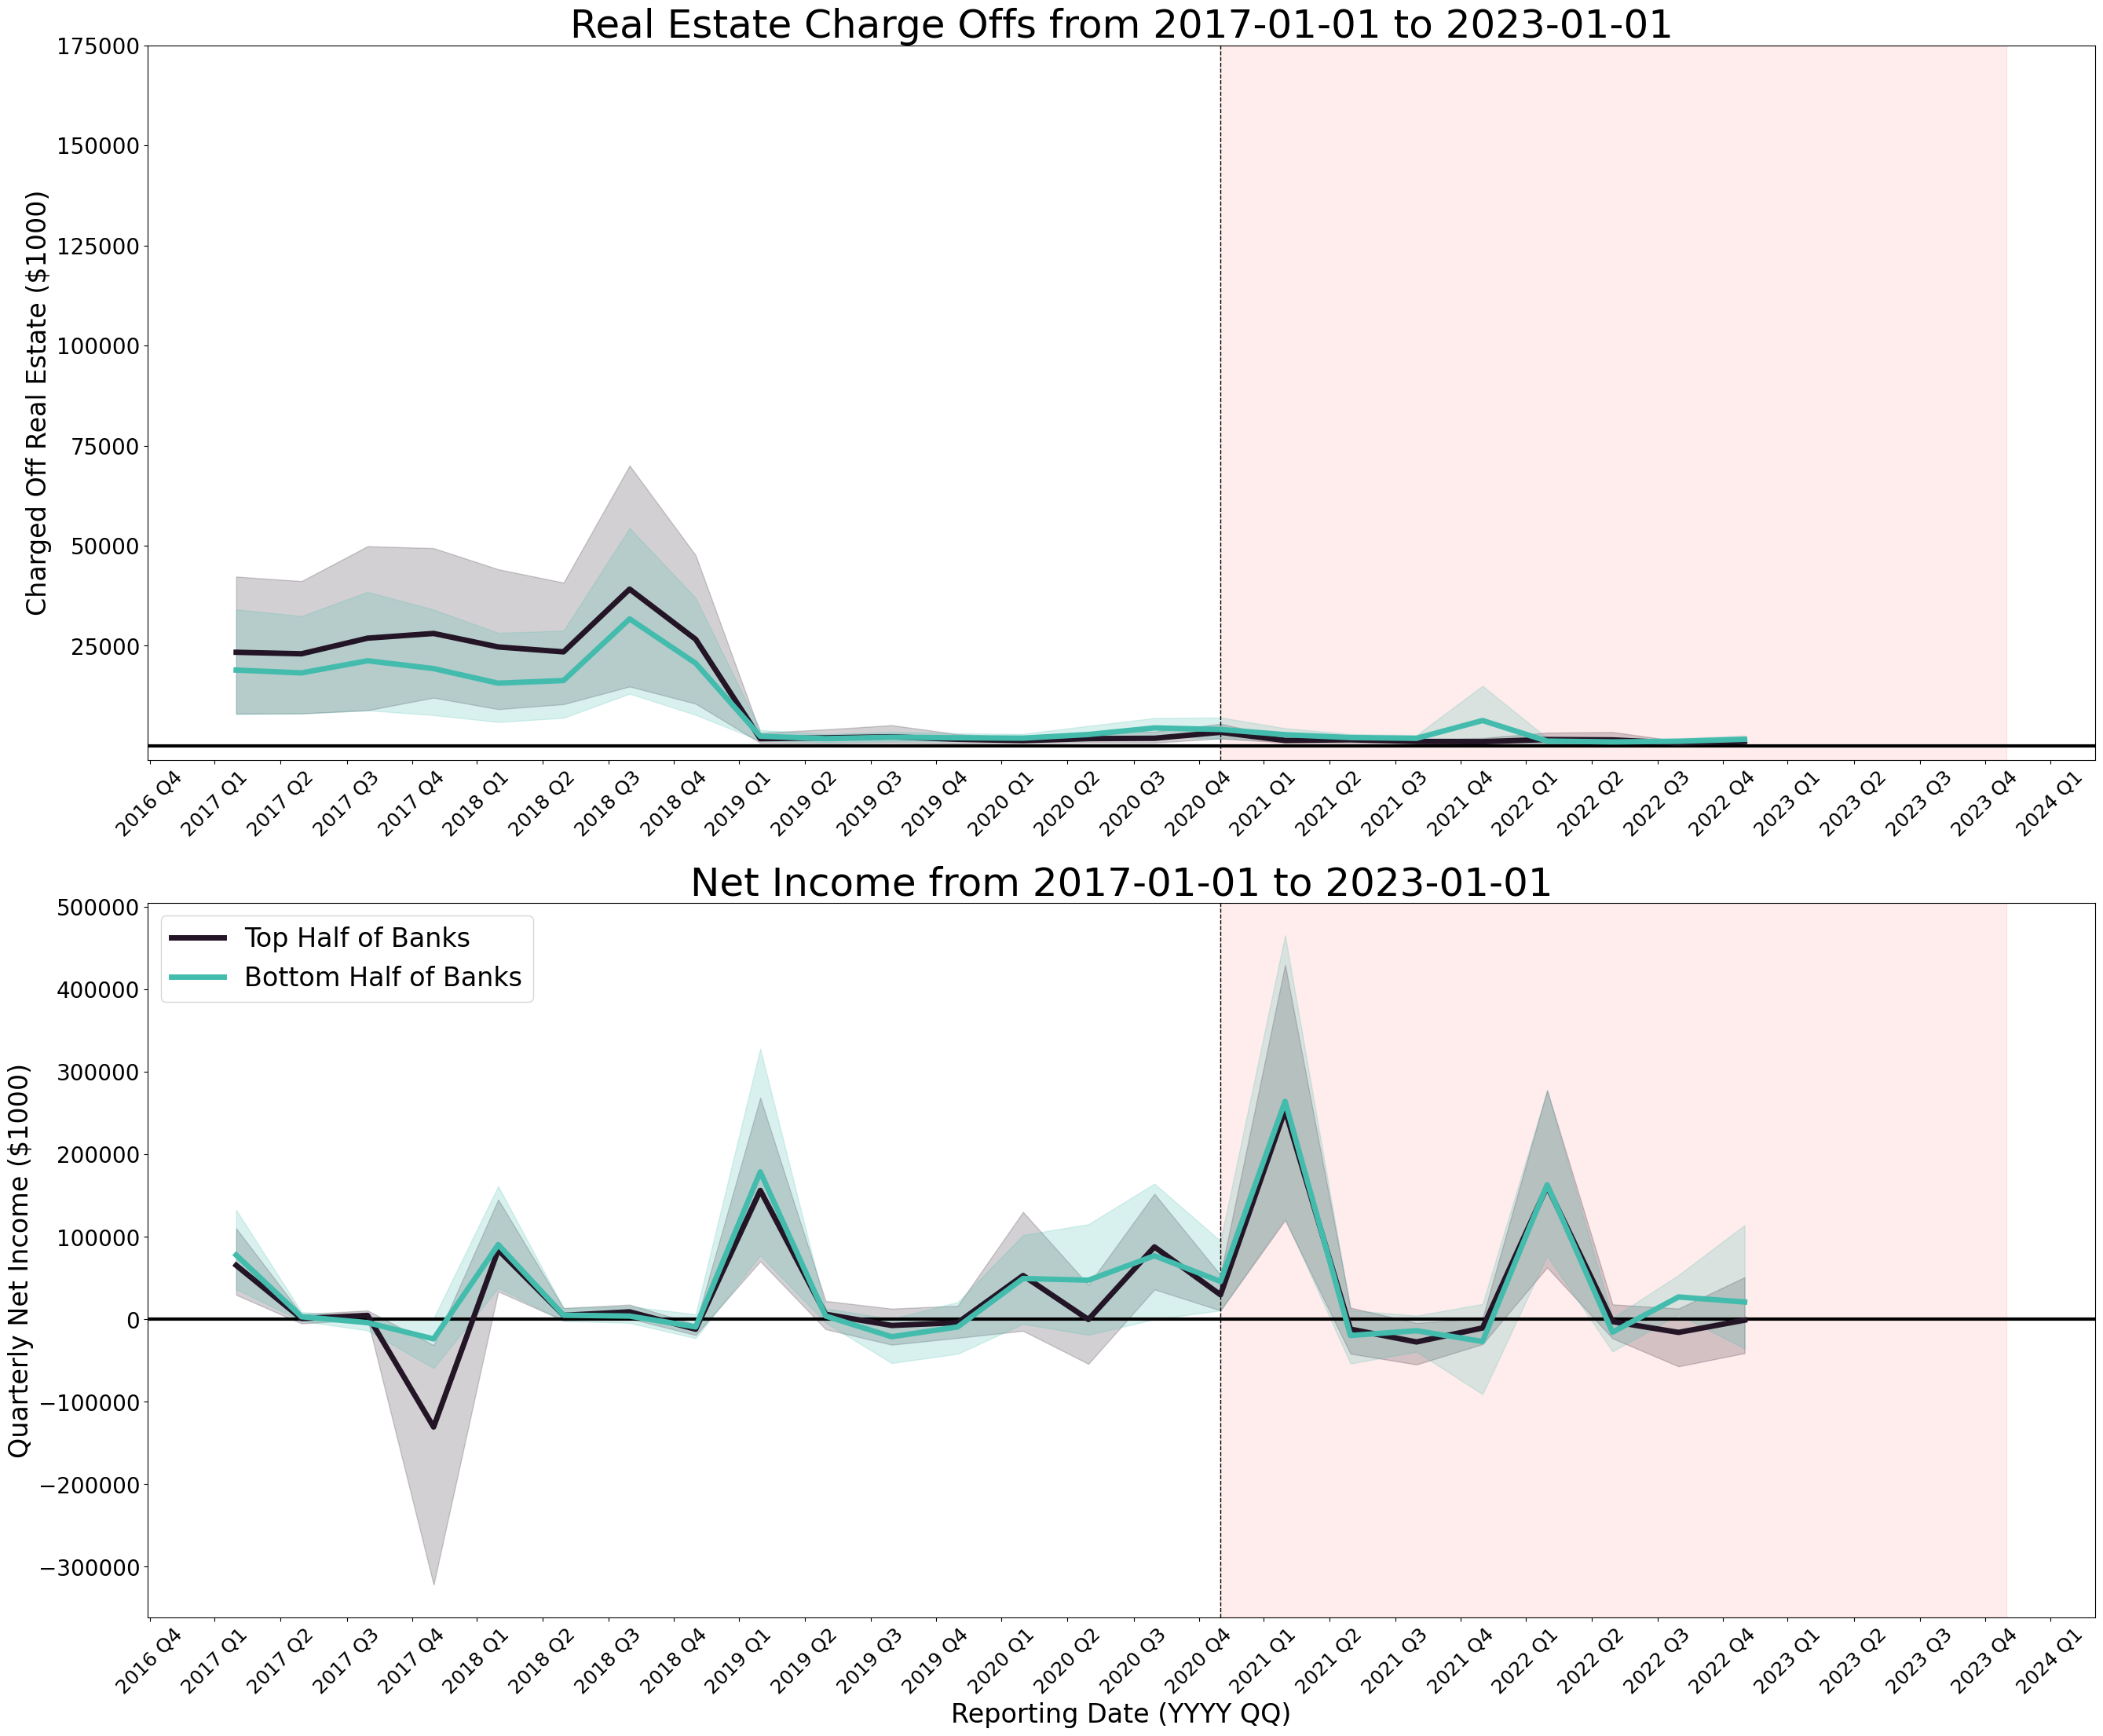

In [27]:
#full figure for covid

#set date range
start_date_string = '2017-01-01'
end_date_string = '2023-01-01'
start_date = pd.to_datetime(start_date_string)
end_date = pd.to_datetime(end_date_string)

#sort and filter the data
sns_combined_df_2020 = combined_df_2.sort_values(['legal_name', 'year', 'quarter'])
sns_combined_df_2020 = combined_df_2[(pd.to_datetime(combined_df_2['quarter']) > start_date) & (pd.to_datetime(combined_df_2['quarter']) < end_date)]

#split banks into top and bottom half
sns_combined_df_top_half_2020 = sns_combined_df_2020[sns_combined_df_2020['legal_name'].isin(set(top_half['legal_name']))]
sns_combined_df_bottom_half_2020 = sns_combined_df_2020[sns_combined_df_2020['legal_name'].isin(set(bottom_half['legal_name']))]

fig, axes = plt.subplots(figsize=(32, 26), nrows = 2)


#set ticks to match the 2008 figure
charge_offs_ticks = [25000, 50000, 75000, 100000, 125000, 150000, 175000]

axes[0].set_title(f'Real Estate Charge Offs from {start_date_string} to {end_date_string}', fontsize = 36)
axes[1].set_title(f'Net Income from {start_date_string} to {end_date_string}', fontsize = 36)

axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

#set ticks as year and quarter for readability
dates = sns_combined_df_2020['quarter']
def quarter_fmt(x, pos):
    d = mdates.num2date(x)
    q = (d.month - 1) // 3 + 1
    return f"{d.year} Q{q}"

axes[0].xaxis.set_major_formatter(quarter_fmt)
axes[1].xaxis.set_major_formatter(quarter_fmt)

#set column to be plotted
y = 'CHARGED_OFF_REAL_ESTATE'

#set vertical lines and shaded area, this time for the covid pandemic
axes[0].axvline(x=pd.Timestamp("2020-12-31"), color='k', linestyle='--', linewidth=1)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=3)
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=3)

axes[0].axvspan(pd.Timestamp("2020-12-31"),
           pd.Timestamp("2023-12-31"),
           color='red',
           alpha=0.075)
axes[1].axvline(x=pd.Timestamp("2020-12-31"), color='k', linestyle='--', linewidth=1)

axes[1].axvspan(pd.Timestamp("2020-12-31"),
           pd.Timestamp("2023-12-31"),
           color='red',
           alpha=0.075)

top_half_color = sns.color_palette("mako", 10)[0]
bottom_half_color = sns.color_palette("mako", 10)[7]

sns.lineplot(data=sns_combined_df_top_half_2020, x='quarter', y=y, ax=axes[0], linewidth=5, color=top_half_color)
sns.lineplot(data=sns_combined_df_bottom_half_2020, x='quarter', y=y, ax=axes[0], linewidth=5, color=bottom_half_color)

sns.lineplot(data=sns_combined_df_top_half_2020, x='quarter', y='Quarterly_NET_INCOME', label = 'Top Half of Banks', ax=axes[1], linewidth=5 ,color=top_half_color)
sns.lineplot(data=sns_combined_df_bottom_half_2020, x='quarter', y='Quarterly_NET_INCOME', label = 'Bottom Half of Banks', ax=axes[1], linewidth=5, color=bottom_half_color)


axes[0].set_yticks(charge_offs_ticks)
axes[0].tick_params(axis='x', rotation=45, labelsize = 18)
axes[0].tick_params(axis='y', labelsize = 20)
axes[0].set_xlabel('')
axes[0].set_ylabel('Charged Off Real Estate ($1000)', fontsize = 24)

axes[1].tick_params(axis='x', rotation=45, labelsize = 18)
axes[1].tick_params(axis='y', labelsize = 20)
axes[1].set_xlabel('Reporting Date (YYYY QQ)', fontsize = 24)
axes[1].set_ylabel('Quarterly Net Income ($1000)', fontsize = 24)

plt.legend(fontsize=24)

plt.savefig('../outputs/2020_Real_Estate_Charge_Offs_And_Net_Income_Full_Figure.png', dpi=300)
